<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Treinamento_de_redes_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import sklearn.datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
dados = sklearn.datasets.load_iris()
#imprimindo algumas informações sobre o conjunto de dados
print("Atributos:", dados['feature_names'])
print("Classes (labels):", dados['target_names'])
print("Dimensões:", dados['data'].shape)

df= pd.DataFrame(dados.data, columns = dados.feature_names)
df['label'] = [dados.target_names[i] for i in dados.target]

Atributos: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes (labels): ['setosa' 'versicolor' 'virginica']
Dimensões: (150, 4)


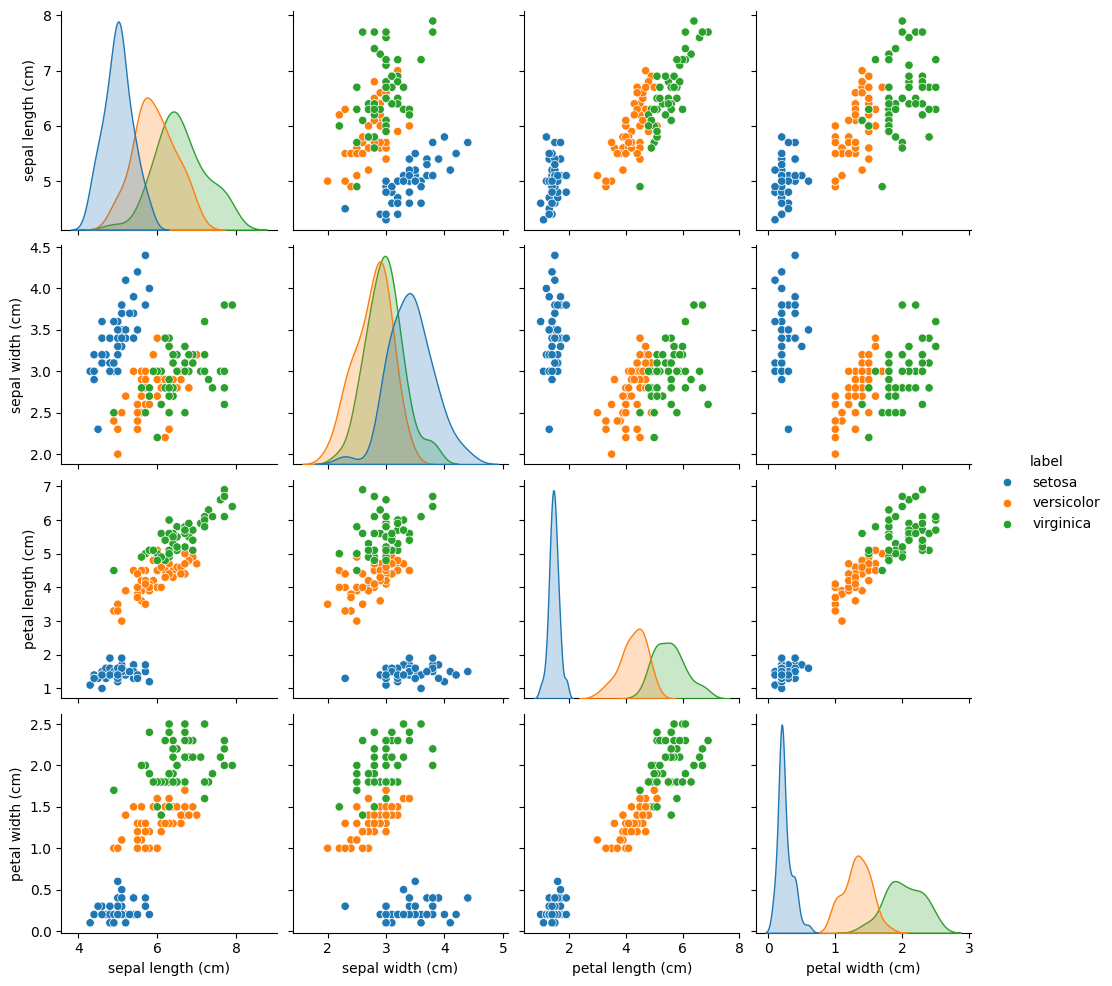

In [5]:
sns.pairplot(df, hue='label')

In [7]:
X = df.drop(['label'], axis = 1)
#normalização dos dados (min - max)
normalizador = MinMaxScaler()
X_norm = pd.DataFrame(normalizador.fit_transform(X), columns=X.columns)
labels = df.label.unique()
print(labels)

# Transformação dos atributos (classes) categóricos em
# numéricos (1-de-c / one-hot-encoding)
# setosa -> 0 0 1
# versicolor -> 0 1 0
#virginica -> 1 0 0

Y = pd.get_dummies(df.label).astype(int)
print(Y)

[np.str_('setosa') np.str_('versicolor') np.str_('virginica')]
     setosa  versicolor  virginica
0         1           0          0
1         1           0          0
2         1           0          0
3         1           0          0
4         1           0          0
..      ...         ...        ...
145       0           0          1
146       0           0          1
147       0           0          1
148       0           0          1
149       0           0          1

[150 rows x 3 columns]


In [11]:
# Separação desenvolvimento (90) e teste (10)
X_dev, X_test, Y_dev, Y_test = train_test_split(X_norm, Y, test_size=0.1, random_state=1)

# Separação treino (80) e validação (20)
X_train, X_val, Y_train, Y_val = train_test_split(X_dev, Y_dev, test_size=0.2, random_state=1)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(108, 4)
(27, 4)
(15, 4)


In [12]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(MLP, self).__init__()
    self.rede = nn.Sequential(
        nn.Linear(input_dim,10),
        nn.Tanh(),
        nn.Linear(10,output_dim),
        nn.Sigmoid(),
    )

  def forward(self, x):
    out = self.rede(x)
    return out


In [13]:
input_dim = 4 # número de atributos da Iris
output_dim = 3 # número de classes

modelo = MLP(input_dim, output_dim) # Criação do modelo

In [14]:
from torchsummary import summary

print(modelo)
summary(modelo, (150,4))

MLP(
  (rede): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=3, bias=True)
    (3): Sigmoid()
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 150, 10]              50
              Tanh-2              [-1, 150, 10]               0
            Linear-3               [-1, 150, 3]              33
           Sigmoid-4               [-1, 150, 3]               0
Total params: 83
Trainable params: 83
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.00
Estimated Total Size (MB): 0.03
----------------------------------------------------------------


In [15]:
eta = 0.2 #taxa de aprendizagem
loss_function = nn.MSELoss() # Erro quadrático médio

# Método do Gradiente Descendente Estocástico
optimizer = torch.optim.SGD(modelo.parameters(), lr=eta)

In [16]:
x_train = torch.FloatTensor(X_train.values)
y_train = torch.FloatTensor(Y_train.values)

x_val = torch.FloatTensor(X_val.values)
y_val = torch.FloatTensor(Y_val.values)

x_test = torch.FloatTensor(X_test.values)
y_test = torch.FloatTensor(Y_test.values)

In [18]:
# Verificando disponibilidade da GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [20]:
def train_network(model, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses):
  for epoch in range(num_epochs):
    # zerando os gradientes da época anterior
    optimizer.zero_grad()

    # fase de propagação
    output_train = model(x_train)

    # cálculo de erro (função de custo - loss function)
    loss_train =  loss_function(output_train, y_train)

    # fase de retropropagação
    loss_train.backward()

    # atualização dos pesos da rede
    optimizer.step()

    # avaliando o modelo com o conjunto de validação
    output_val = model(x_val)

    # avaliando o modelo com o conjunto de validação
    output_val = model(x_val)
    loss_val = loss_function(output_val, y_val)

    train_losses[epoch] = loss_train.item()
    val_losses[epoch] = loss_val.item()

    if (epoch + 1) % 100 == 0:
      print(f"Epoch {epoch+1}/{num_epochs}, Erro Treino: {loss_train.item():.4f}, Erro Validação: {loss_val.item():.4f}")


In [21]:
num_epochs = 5000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

train_network(modelo, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses)

Epoch 100/5000, Erro Treino: 0.2119, Erro Validação: 0.2267
Epoch 200/5000, Erro Treino: 0.1897, Erro Validação: 0.2040
Epoch 300/5000, Erro Treino: 0.1544, Erro Validação: 0.1613
Epoch 400/5000, Erro Treino: 0.1291, Erro Validação: 0.1302
Epoch 500/5000, Erro Treino: 0.1169, Erro Validação: 0.1150
Epoch 600/5000, Erro Treino: 0.1099, Erro Validação: 0.1063
Epoch 700/5000, Erro Treino: 0.1048, Erro Validação: 0.1002
Epoch 800/5000, Erro Treino: 0.1005, Erro Validação: 0.0952
Epoch 900/5000, Erro Treino: 0.0966, Erro Validação: 0.0908
Epoch 1000/5000, Erro Treino: 0.0929, Erro Validação: 0.0867
Epoch 1100/5000, Erro Treino: 0.0892, Erro Validação: 0.0827
Epoch 1200/5000, Erro Treino: 0.0855, Erro Validação: 0.0788
Epoch 1300/5000, Erro Treino: 0.0818, Erro Validação: 0.0749
Epoch 1400/5000, Erro Treino: 0.0780, Erro Validação: 0.0709
Epoch 1500/5000, Erro Treino: 0.0742, Erro Validação: 0.0669
Epoch 1600/5000, Erro Treino: 0.0704, Erro Validação: 0.0630
Epoch 1700/5000, Erro Treino: 0.0

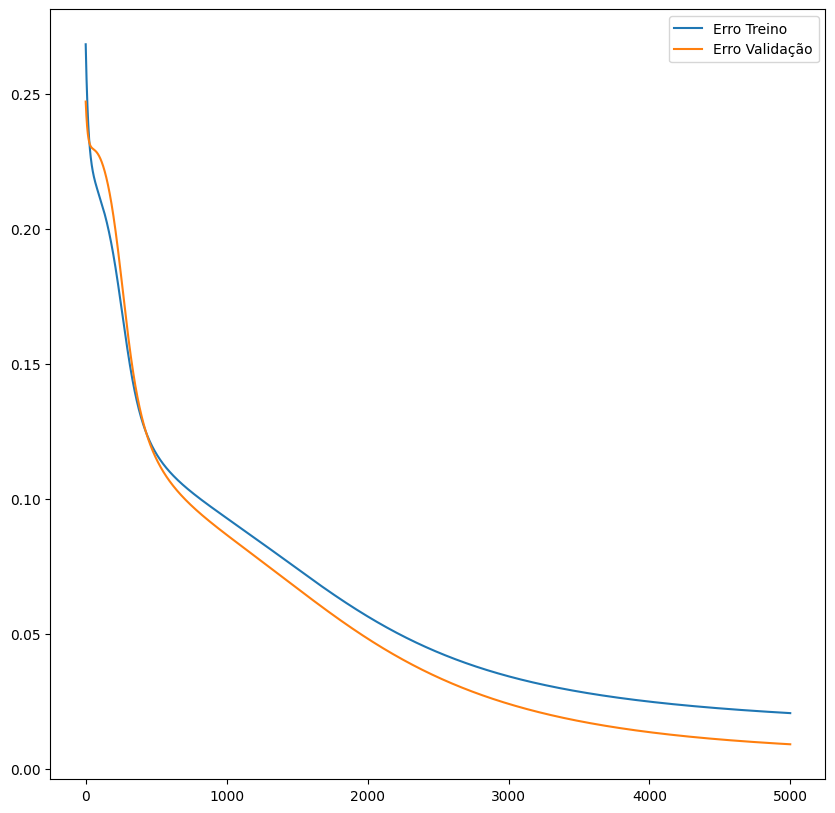

In [22]:
plt.figure(figsize=(10,10))
plt.plot(train_losses, label='Erro Treino')
plt.plot(val_losses, label='Erro Validação')
plt.legend()
plt.show()

In [23]:
predictions_train = []
predictions_val = []
predictions_test = []
with torch.no_grad():
  predictions_train = modelo(x_train)
  predictions_val = modelo(x_val)
  predictions_test = modelo(x_test)


  # Cálculo do erro (Função de Custo)
  erro_train = loss_function(predictions_train, y_train)
  erro_val = loss_function(predictions_val, y_val)
  erro_test = loss_function(predictions_test, y_test)

  print(f"Erro de Treino: {erro_train}")
  print(f"Erro de Validação: {erro_val}")
  print(f"Erro de Teste: {erro_test}")

Erro de Treino: 0.020582253113389015
Erro de Validação: 0.009039239026606083
Erro de Teste: 0.008427951484918594


In [24]:
pred_train = torch.argmax(predictions_train, dim=1)
labels_train = torch.argmax(y_train, dim=1)
pred_val = torch.argmax(predictions_val, dim=1)
labels_val = torch.argmax(y_val, dim=1)
pred_test = torch.argmax(predictions_test, dim=1)
label_test = torch.argmax(y_test, dim=1)

from sklearn.metrics import accuracy_score
acc_train = accuracy_score(labels_train, pred_train)
acc_val = accuracy_score(labels_val, pred_val)
acc_test = accuracy_score(label_test, pred_test)

print(f"Acurácia de Treino: {acc_train*100:.2f}%")
print(f"Acurácia de Validação: {acc_val*100:.2f}%")
print(f"Acurácia de Teste: {acc_test*100:.2f}%")

Acurácia de Treino: 96.30%
Acurácia de Validação: 100.00%
Acurácia de Teste: 100.00%


In [26]:
# torch.manual_seed(7) # aprende as portas Not-AND e Not-OR
torch.manual_seed(9) # aprende as portas AND e OR

class MLPXor(nn.Module):
  def __init__(self):
    super(MLPXor, self).__init__()
    self.hidden = nn.Linear(2,2)
    self.output = nn.Linear(2,1)
  def forward(self, x):
    hidden = self.hidden(x)
    x1 = torch.sigmoid(hidden)
    output = self.output(x1)
    x2 = torch.sigmoid(output)
    return x2, x1

In [28]:
modeloXOR = MLPXor() # Criando modelo
print(modeloXOR)
summary(modeloXOR, (150,2))

MLPXor(
  (hidden): Linear(in_features=2, out_features=2, bias=True)
  (output): Linear(in_features=2, out_features=1, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 150, 2]               6
            Linear-2               [-1, 150, 1]               3
Total params: 9
Trainable params: 9
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [29]:
loss_function = nn.MSELoss() # Erro quadrático médio
optimizer = torch.optim.SGD(modeloXOR.parameters(), lr=0.2, momentum=0.9)

In [30]:
x_xor = torch.Tensor([[0,0],[0,1],[1,0],[1,1]])
y_xor = torch.Tensor([0,1,1,0]).view(-1,1)

print(x_xor)
print(y_xor)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [31]:
from torch.autograd import Variable

def train_xor(model, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses):
  for epoch in range(num_epochs):
    for j in range(4):
      exemplo = np.random.randint(4)
      x = Variable(x_xor[exemplo], requires_grad=False)
      y = Variable(y_xor[exemplo], requires_grad=False)

      optimizer.zero_grad()
      y_hat, _ = modeloXOR(x)
      loss_train = loss_function.forward(y_hat, y)
      loss_train.backward()
      optimizer.step()
      train_losses[epoch] = loss_train.item()

      if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Erro Treino: {loss_train.item():.4f}")


In [33]:
num_epochs = 5000
train_losses = np.zeros(num_epochs)
train_xor(modeloXOR, optimizer, loss_function, x_xor, y_xor, x_xor, y_xor, num_epochs, train_losses, val_losses)

Epoch 1000/5000, Erro Treino: 0.3120
Epoch 1000/5000, Erro Treino: 0.0001
Epoch 1000/5000, Erro Treino: 0.0001
Epoch 1000/5000, Erro Treino: 0.2235
Epoch 2000/5000, Erro Treino: 0.2101
Epoch 2000/5000, Erro Treino: 0.2865
Epoch 2000/5000, Erro Treino: 0.2658
Epoch 2000/5000, Erro Treino: 0.0001
Epoch 3000/5000, Erro Treino: 0.2074
Epoch 3000/5000, Erro Treino: 0.1870
Epoch 3000/5000, Erro Treino: 0.3585
Epoch 3000/5000, Erro Treino: 0.3747
Epoch 4000/5000, Erro Treino: 0.0000
Epoch 4000/5000, Erro Treino: 0.0001
Epoch 4000/5000, Erro Treino: 0.0001
Epoch 4000/5000, Erro Treino: 0.0000
Epoch 5000/5000, Erro Treino: 0.0000
Epoch 5000/5000, Erro Treino: 0.5439
Epoch 5000/5000, Erro Treino: 0.0000
Epoch 5000/5000, Erro Treino: 0.0827


In [34]:
predictions, hidden = modeloXOR(x_xor)
pred = predictions > 0.5
hid = hidden > 0.5
print(x_xor)
print(predictions)
print(hidden)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
tensor([[0.0014],
        [0.9899],
        [0.2934],
        [0.2936]], grad_fn=<SigmoidBackward0>)
tensor([[7.4393e-02, 7.7328e-01],
        [7.6729e-01, 1.3749e-02],
        [1.8370e-06, 7.0264e-05],
        [7.5357e-05, 2.8722e-07]], grad_fn=<SigmoidBackward0>)


In [35]:
print("Saídas do modelo")
print(pred)
print("Saídas da camada oculta")
print(hid)

Saídas do modelo
tensor([[False],
        [ True],
        [False],
        [False]])
Saídas da camada oculta
tensor([[False,  True],
        [ True, False],
        [False, False],
        [False, False]])
